In [7]:
!pip install casadi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 10.6 MB/s eta 0:00:00


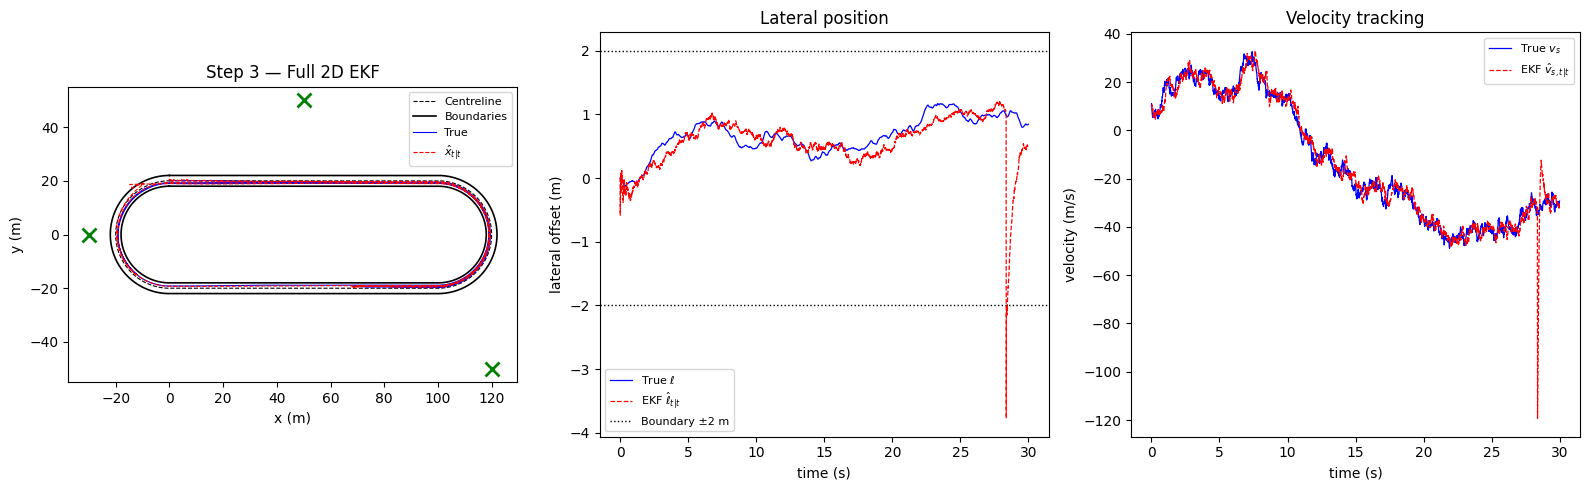

mean arc-length error : 0.372 m
mean lateral error    : 0.188 m
lateral bounds OK     : True


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

# Track geometry — from track_model.ipynb (member A: ChenhuiCui)
d   = 100.0
rho = 20.0
L   = 2*d + 2*np.pi*rho

def s_to_xy(s):
    s = s % L
    if s < d:
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])

def s_to_normal(s):
    s = s % L
    if s < d:
        return np.array([0.0, -1.0])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([-np.sin(theta), -np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([0.0, 1.0])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([np.sin(theta), np.cos(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# system parameters
h   = 0.01
phi = 0.9

# x_t = [s, ell, v_s, v_ell]
A = np.array([
    [1, 0, h,   0  ],
    [0, 1, 0,   h  ],
    [0, 0, 1,   0  ],
    [0, 0, 0, phi  ]
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])

Q_mat = np.diag([0.5, 0.02])
R     = 1.5**2

beacons = np.array([
    [ 50.0,  50.0],
    [120.0, -50.0],
    [-30.0,   0.0]
])
nb  = len(beacons)
nx  = 4
nv  = nb

# --- CasADi: define symbolic measurement function h(z, v) ---
# following teacher's style in 5_ekf.ipynb
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', nv)

s_   = z_[0]
ell_ = z_[1]

# s_to_xy and s_to_normal in CasADi symbolic form
s_mod = cs.fmod(s_, L)

# segment 1: s < d
xy1  = cs.vertcat(s_mod, rho)
n1   = cs.vertcat(0.0, -1.0)

# segment 2: d <= s < d + pi*rho
theta2 = (s_mod - d) / rho
xy2  = cs.vertcat(d + rho*cs.sin(theta2), rho*cs.cos(theta2))
n2   = cs.vertcat(-cs.sin(theta2), -cs.cos(theta2))

# segment 3: d+pi*rho <= s < 2d+pi*rho
xy3  = cs.vertcat(2*d + np.pi*rho - s_mod, -rho)
n3   = cs.vertcat(0.0, 1.0)

# segment 4: s >= 2d+pi*rho
theta4 = (s_mod - (2*d + np.pi*rho)) / rho
xy4  = cs.vertcat(-rho*cs.sin(theta4), -rho*cs.cos(theta4))
n4   = cs.vertcat(cs.sin(theta4), cs.cos(theta4))

# piecewise using cs.if_else
xy_c = cs.if_else(s_mod < d, xy1,
       cs.if_else(s_mod < d + np.pi*rho, xy2,
       cs.if_else(s_mod < 2*d + np.pi*rho, xy3, xy4)))

n_c  = cs.if_else(s_mod < d, n1,
       cs.if_else(s_mod < d + np.pi*rho, n2,
       cs.if_else(s_mod < 2*d + np.pi*rho, n3, n4)))

pos_ = xy_c + ell_ * n_c

# measurement: y_i = ||pos - beacon_i|| + v_i
h_ = cs.vertcat(*[
    cs.norm_2(pos_ - beacons[i]) + v_[i]
    for i in range(nb)
])

# Jacobians — automatic differentiation (from 5_ekf.ipynb)
jhx_ = cs.jacobian(h_, z_)
jhv_ = cs.jacobian(h_, v_)

h_fn   = cs.Function('h',   [z_, v_], [h_])
jhx_fn = cs.Function('jhx', [z_, v_], [jhx_])
jhv_fn = cs.Function('jhv', [z_, v_], [jhv_])


# --- EKF functions — following teacher's style in 5_ekf.ipynb ---
def measurement_update(sigma_pred, x_pred, y):
    C     = np.array(jhx_fn(x_pred.flatten(), np.zeros(nv)))
    Rv    = np.array(jhv_fn(x_pred.flatten(), np.zeros(nv)))
    R_tilde = Rv @ (R * np.eye(nv)) @ Rv.T
    S     = C @ sigma_pred @ C.T + R_tilde
    innov = np.array(y - h_fn(x_pred.flatten(), np.zeros(nv))).flatten()
    x_meas     = x_pred.flatten() + sigma_pred @ C.T @ np.linalg.solve(S, innov)
    sigma_meas = sigma_pred - sigma_pred @ C.T @ np.linalg.solve(S, C @ sigma_pred)
    return np.array(sigma_meas), x_meas.flatten()
def time_update(sigma_meas, x_meas):
    x_pred    = A @ x_meas
    x_pred[1] = np.clip(x_pred[1], -2.0, 2.0)
    sigma_pred = A @ sigma_meas @ A.T + G @ Q_mat @ G.T
    return np.array(sigma_pred), np.array(x_pred)


# --- simulation ---
N      = 3000
x_t    = np.array([0.0, 0.0, 10.0, 0.0])
x_pred = np.array([0.0, 0.0, 10.0, 0.0])
sigma_pred = np.diag([100.0, 1.0, 25.0, 0.5])

x_cache      = np.zeros((N, nx))
x_meas_cache = np.zeros((N-1, nx))
x_cache[0]   = x_t

for t in range(N - 1):
    # i. obtain measurement
    v_t = np.random.normal(0, 1.5, nb)
    y_t = np.array(h_fn(x_t, v_t))

    # ii. measurement update
    sigma_meas, x_meas   = measurement_update(sigma_pred, x_pred, y_t)
    x_meas_cache[t]      = x_meas.flatten()

    # iii. time update
    sigma_pred, x_pred   = time_update(sigma_meas, x_meas)

    # iv. dynamics
    w_t    = np.array([np.random.normal(0, np.sqrt(Q_mat[0,0])),
                       np.random.normal(0, np.sqrt(Q_mat[1,1]))])
    x_t    = A @ x_t + G @ w_t
    x_t[1] = np.clip(x_t[1], -2.0, 2.0)
    x_cache[t+1] = x_t

# --- plots ---
s_vals   = np.linspace(0, L, 500)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  2.0) for s in s_vals])
true_xy  = np.array([sl_to_xy(x_cache[t,0], x_cache[t,1]) for t in range(N)])
est_xy   = np.array([sl_to_xy(x_meas_cache[t,0], x_meas_cache[t,1]) for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b-',  lw=0.8, label='True')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.8, label=r'$\hat{x}_{t|t}$')
for b in beacons:
    axes[0].plot(b[0], b[1], 'gx', ms=10, mew=2)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].legend(fontsize=8); axes[0].set_title('Step 3 — Full 2D EKF')

t_ax = np.arange(N) * h
axes[1].plot(t_ax,      x_cache[:,1],      'b-',  lw=0.9, label=r'True $\ell$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', lw=0.9, label=r'EKF $\hat{\ell}_{t|t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1.0, label='Boundary ±2 m')
axes[1].axhline(-2.0, color='k', ls=':', lw=1.0)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('lateral offset (m)')
axes[1].legend(fontsize=8); axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b-',  lw=0.9, label=r'True $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', lw=0.9, label=r'EKF $\hat{v}_{s,t|t}$')
axes[2].set_xlabel('time (s)'); axes[2].set_ylabel('velocity (m/s)')
axes[2].legend(fontsize=8); axes[2].set_title('Velocity tracking')

plt.tight_layout()
plt.show()

print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')
print(f'mean lateral error    : {np.mean(np.abs(x_cache[:-1,1]-x_meas_cache[:,1])):.3f} m')
print(f'lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= 2.0)}')